In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

In [99]:
warnings.filterwarnings('ignore')

In [100]:
df_netflix = pd.read_csv('netflix_titles.csv')

In [123]:
df_netflix.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...


In [124]:
# data types
df_netflix.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [103]:
# shape of dataframe
df_netflix.shape

(8807, 12)

# Identifying Missing Data

In [104]:
# % of rows missing in each column


In [105]:
for column in df_netflix.columns:
   percentage =  df_netflix[column].isna().agg('mean')
   print(str(round(percentage*100, 2) ) + "   " + column)

0.0   show_id
0.0   type
0.0   title
29.91   director
9.37   cast
9.44   country
0.11   date_added
0.0   release_year
0.05   rating
0.03   duration
0.0   listed_in
0.0   description


In [106]:
df_netflix =  df_netflix.dropna(subset=['director'])

In [107]:
for col in df_netflix.columns:
    if df_netflix[col].isnull().any():  
        mode_value = df_netflix[col].mode()[0]  
        df_netflix[col] = df_netflix[col].fillna(mode_value) 

In [108]:
df_netflix.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

###  Remove duplicates 

In [109]:
df_netflix.drop_duplicates(inplace=True)

In [110]:
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."


### Data is clean and ready

In [111]:
df_movie = df_netflix[df_netflix['type'] == 'Movie']

In [112]:
df_movie['minute'] = df_movie['duration'].str.split(expand=True)[0].astype(int)

In [113]:
df_movie['date_added'].str.split(expand=True)[2].astype(int)

0       2021
6       2021
7       2021
9       2021
12      2021
        ... 
8801    2016
8802    2019
8804    2019
8805    2020
8806    2019
Name: 2, Length: 5943, dtype: int64

In [114]:
df_movie.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,minute
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127


## Identifying Outliers

#### Removig Outliers

In [115]:
# Formula for fiding outliers
# LowerFence  = Q1 - 1.5(IQR)
#   Q1 = 25% of the dataset
# HigerFence  = Q3 + 1.5(IQR)
#   Q3 is 75% of the dataset

In [116]:
df_movie['minute'].describe()

count    5943.000000
mean      100.533569
std        27.398050
min         1.000000
25%        88.000000
50%        99.000000
75%       115.000000
max       253.000000
Name: minute, dtype: float64

In [117]:
min_value = 88 - 1.5*(115-88)
print(min_value)

47.5


In [118]:
max_value = 115 + 1.5*(115-88)
print(max_value)

155.5


In [119]:
df_movie = df_movie[(df_movie['minute'] > 47.5) & (df_movie['minute'] < 155.5)]

Text(0.5, 0, 'Minutes')

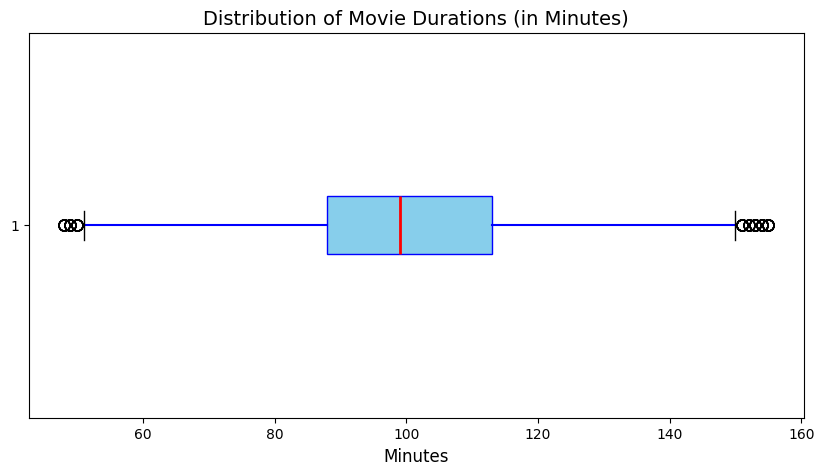

In [120]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_movie['minute'], vert=False, patch_artist=True, 
            boxprops=dict(facecolor='skyblue', color='blue'),
            whiskerprops=dict(color='blue', linewidth=1.5),
            flierprops=dict(marker='o', color='red', markersize=8),
            medianprops=dict(color='red', linewidth=2))
plt.title('Distribution of Movie Durations (in Minutes)', fontsize=14)
plt.xlabel('Minutes', fontsize=12)


In [121]:
df_movie

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,minute
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8799,s8800,Movie,Zenda,Avadhoot Gupte,"Santosh Juvekar, Siddharth Chandekar, Sachit P...",India,"February 15, 2018",2009,TV-14,120 min,"Dramas, International Movies",A change in the leadership of a political part...,120
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,96
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88
